In [33]:
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
import numpy as np
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV

In [24]:
#data = pd.read_csv("/Users/abhinavmohanty/Documents/Python/Python - Exploration/Jaga/Completed/spam.csv",encoding='latin-1')
data = pd.read_csv("../DataSets/spam.csv",encoding='latin-1')
#print(data.head())
#print(data.columns)
#print(data.info())
data = data.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1)
data = data.rename(columns={"v1":"label", "v2":"text"})
#print(data.head())
#print(data.tail())

In [25]:
print(data.label.value_counts())

data['label_num'] = data.label.map({'ham':0, 'spam':1})
#print(data.head())
#print(data.tail())

ham     4825
spam     747
Name: label, dtype: int64


In [26]:
ham_words = ''
spam_words = ''
#ABhinav_words = ''
spam = data[data.label_num == 1]
ham = data[data.label_num ==0]
#print(spam)

In [27]:
for val in spam.text:
    text = val.lower()
    tokens = nltk.word_tokenize(text)
    tokens = [word for word in tokens if word not in stopwords.words('english')]
    for words in tokens:
        spam_words = spam_words + words + ' '

for val in ham.text:
    text = val.lower()
    tokens = nltk.word_tokenize(text)
    tokens = [word for word in tokens if word not in stopwords.words('english')]
    for words in tokens:
        ham_words = ham_words + words + ' '

#print(type(ham_words))
#print(type(ham))
#print(ham_words) 
#ABhinav = ['Data Management', 'Data Integration', 'Data Ingestion', 'Data Engineering', 'Data Governance', 'Data Quality', 'Data Analytics']
#for val in ABhinav:
 #   ABhinav_words = ABhinav_words + val + ' '

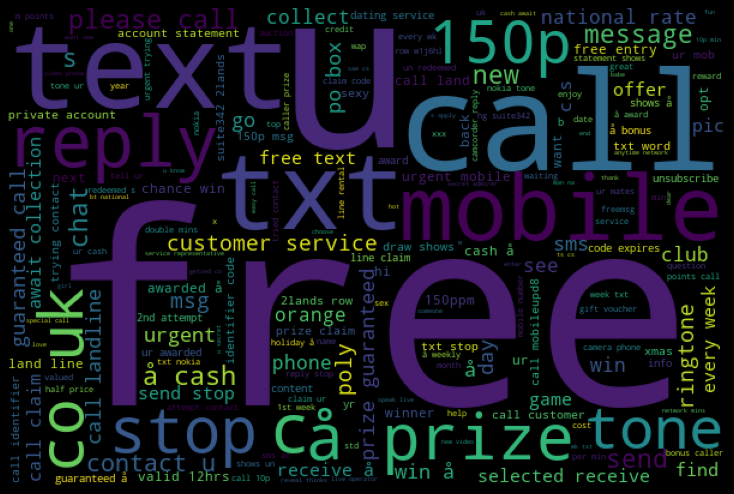

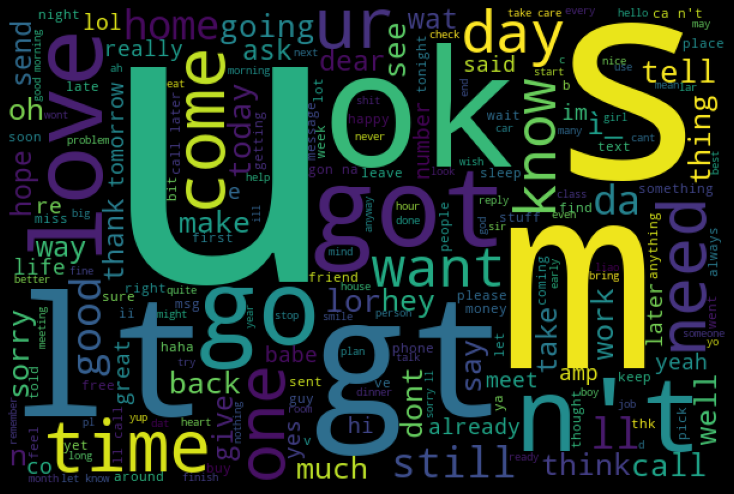

In [28]:
# Generate a word cloud image
spam_wordcloud = WordCloud(width=600, height=400).generate(spam_words)
ham_wordcloud = WordCloud(width=600, height=400).generate(ham_words)
#ABhinav_wordcloud = WordCloud(width=600, height=400).generate(ABhinav_words)

#Spam Word cloud
plt.figure(figsize=(10,8), facecolor='k') #one of {'b', 'g', 'r', 'c', 'm', 'y', 'k', 'w'}
plt.imshow(spam_wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

#Ham word cloud
plt.figure( figsize=(10,8), facecolor='k')
plt.imshow(ham_wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

#ABhinav word cloud
#plt.figure( figsize=(10,8), facecolor='k')
#plt.imshow(ABhinav_wordcloud)
#plt.axis("off")
#plt.tight_layout(pad=0)
#plt.show()

In [29]:
X_train,X_test,y_train,y_test = train_test_split(data["text"],data["label"], test_size = 0.2, random_state = 10)
#print(X_train.shape)
#print(X_test.shape)
#print(y_train.shape)
#print(y_test.shape)

vect = CountVectorizer()
vect.fit(X_train)
#print(vect.fit(X_train))

vect.get_feature_names()[0:20]
vect.get_feature_names()[-20:]
#print(vect.get_feature_names()[-20:])

X_train_df = vect.transform(X_train)
X_test_df = vect.transform(X_test)
#print(X_test_df)
#print(type(X_test_df))

In [30]:
prediction = dict()
model = MultinomialNB()
model.fit(X_train_df,y_train)
prediction["Multinomial"] = model.predict(X_test_df)

print('Accuracy using MultinomialNB:',accuracy_score(y_test,prediction["Multinomial"]))

Accuracy using MultinomialNB: 0.9883408071748879


In [31]:
model = LogisticRegression()
model.fit(X_train_df,y_train)
prediction["Logistic"] = model.predict(X_test_df)
print('Accuracy using LogicticRegression:',accuracy_score(y_test,prediction["Logistic"]))

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_df,y_train)
prediction["knn"] = model.predict(X_test_df)
print('Accuracy using KNeighborsClassifier:',accuracy_score(y_test,prediction["knn"]))

model = RandomForestClassifier()
model.fit(X_train_df,y_train)
prediction["random_forest"] = model.predict(X_test_df)
print('Accuracy using RandomForestClassifier:',accuracy_score(y_test,prediction["random_forest"]))

model = AdaBoostClassifier()
model.fit(X_train_df,y_train)
prediction["adaboost"] = model.predict(X_test_df)
print('Accuracy using AdaBoostClassifier:',accuracy_score(y_test,prediction["adaboost"]))

Accuracy using LogicticRegression: 0.97847533632287
Accuracy using KNeighborsClassifier: 0.9121076233183857
Accuracy using RandomForestClassifier: 0.967713004484305
Accuracy using AdaBoostClassifier: 0.967713004484305


In [34]:
#ABContinue
k_range = np.arange(1,30)
#print(k_range)
param_grid = dict(n_neighbors=k_range)
print(param_grid)

{'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29])}


In [35]:
model = KNeighborsClassifier()
grid = GridSearchCV(model,param_grid)
grid.fit(X_train_df,y_train)

print(grid.best_estimator_)
print(grid.best_params_)
print(grid.best_score_)

KNeighborsClassifier(n_neighbors=1)
{'n_neighbors': 1}
0.9497425676797875


In [36]:
print(classification_report(y_test, prediction['Multinomial'], target_names = ["Ham", "Spam"]))
conf_mat = confusion_matrix(y_test, prediction['Multinomial'])
conf_mat_normalized = conf_mat.astype('float') / conf_mat.sum(axis=1)[:, np.newaxis]

print(conf_mat)

              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       965
        Spam       0.97      0.95      0.96       150

    accuracy                           0.99      1115
   macro avg       0.98      0.97      0.97      1115
weighted avg       0.99      0.99      0.99      1115

[[960   5]
 [  8 142]]


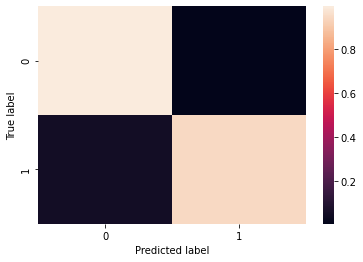

573     Waiting for your call.                                                                                                      
4727    I (Career Tel) have added u as a contact on INDYAROCKS.COM to send FREE SMS. To remove from phonebook - sms NO to  &lt;#&gt;
5475    Dhoni have luck to win some big title.so we will win:)                                                                      
4860    Nokia phone is lovly..                                                                                                      
1259    We have sent JD for Customer Service cum Accounts Executive to ur mail id, For details contact us                           
Name: text, dtype: object
5035    You won't believe it but it's true. It's Incredible Txts! Reply G now to learn truly amazing things that will blow your mind. From O2FWD only 18p/txt       
2574    Your next amazing xxx PICSFREE1 video will be sent to you enjoy! If one vid is not enough for 2day text back the keyword PICSFREE1 to ge

In [37]:
sns.heatmap(conf_mat_normalized)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

pd.set_option('display.max_colwidth', -1)
print(X_test[y_test < prediction["Multinomial"] ])
print(X_test[y_test > prediction["Multinomial"] ])

#print(sorted(prediction.items())[:10])
print(prediction)
print(grid)